# Clustering and differential expression


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pyclustree import clustree

sc.settings.set_figure_params(dpi=140, facecolor="white", frameon=False)


In [ ]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SOURCE_DATA_ROOT = Path(
    os.environ.get("EPEN_SOURCE_DATA", REPO_ROOT.parent / "analysis" / "anndata")
).expanduser().resolve()
OUTPUT_ROOT = Path(
    os.environ.get("EPEN_OUTPUT_DIR", REPO_ROOT / "outputs")
).expanduser().resolve()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCRIPTS_DIR = REPO_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

def prefer_checkpoint(local_name, source_path):
    local_path = OUTPUT_ROOT / local_name
    return local_path if local_path.exists() else SOURCE_DATA_ROOT / source_path


In [ ]:
HARMONY_CHECKPOINT = prefer_checkpoint(
    "03_harmony.h5ad", "2000HVG_rg_cc_mt/Gill_Wu_ZhangQ_ZangD_cc_mt_inter.h5ad"
)
CLUSTERED_CHECKPOINT = prefer_checkpoint(
    "04_clustered.h5ad", "2000HVG_rg_cc_mt/clustered_niter.h5ad"
)


## Load Harmony checkpoint


In [ ]:
adata = sc.read_h5ad(HARMONY_CHECKPOINT)

if "neighbors" not in adata.uns:
    sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca_harmony")
if "X_umap" not in adata.obsm:
    sc.tl.umap(adata)
adata


## Leiden resolution sweep


In [ ]:
resolutions = [
    0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09,
    0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0,
]
for resolution in resolutions:
    sc.tl.leiden(
        adata,
        resolution=resolution,
        flavor="igraph",
        n_iterations=2,
        key_added=f"leiden_{str(resolution).replace('.', '_')}",
    )


In [ ]:
fig = clustree(
    adata,
    [f"leiden_{str(resolution).replace('.', '_')}" for resolution in resolutions],
    title="Clustering-resolution tree",
    edge_weight_threshold=0.0,
    show_fraction=True,
)
fig.set_size_inches(20, 35)
fig.set_dpi(100)


Leiden resolution 0.4 was used for the final analysis.


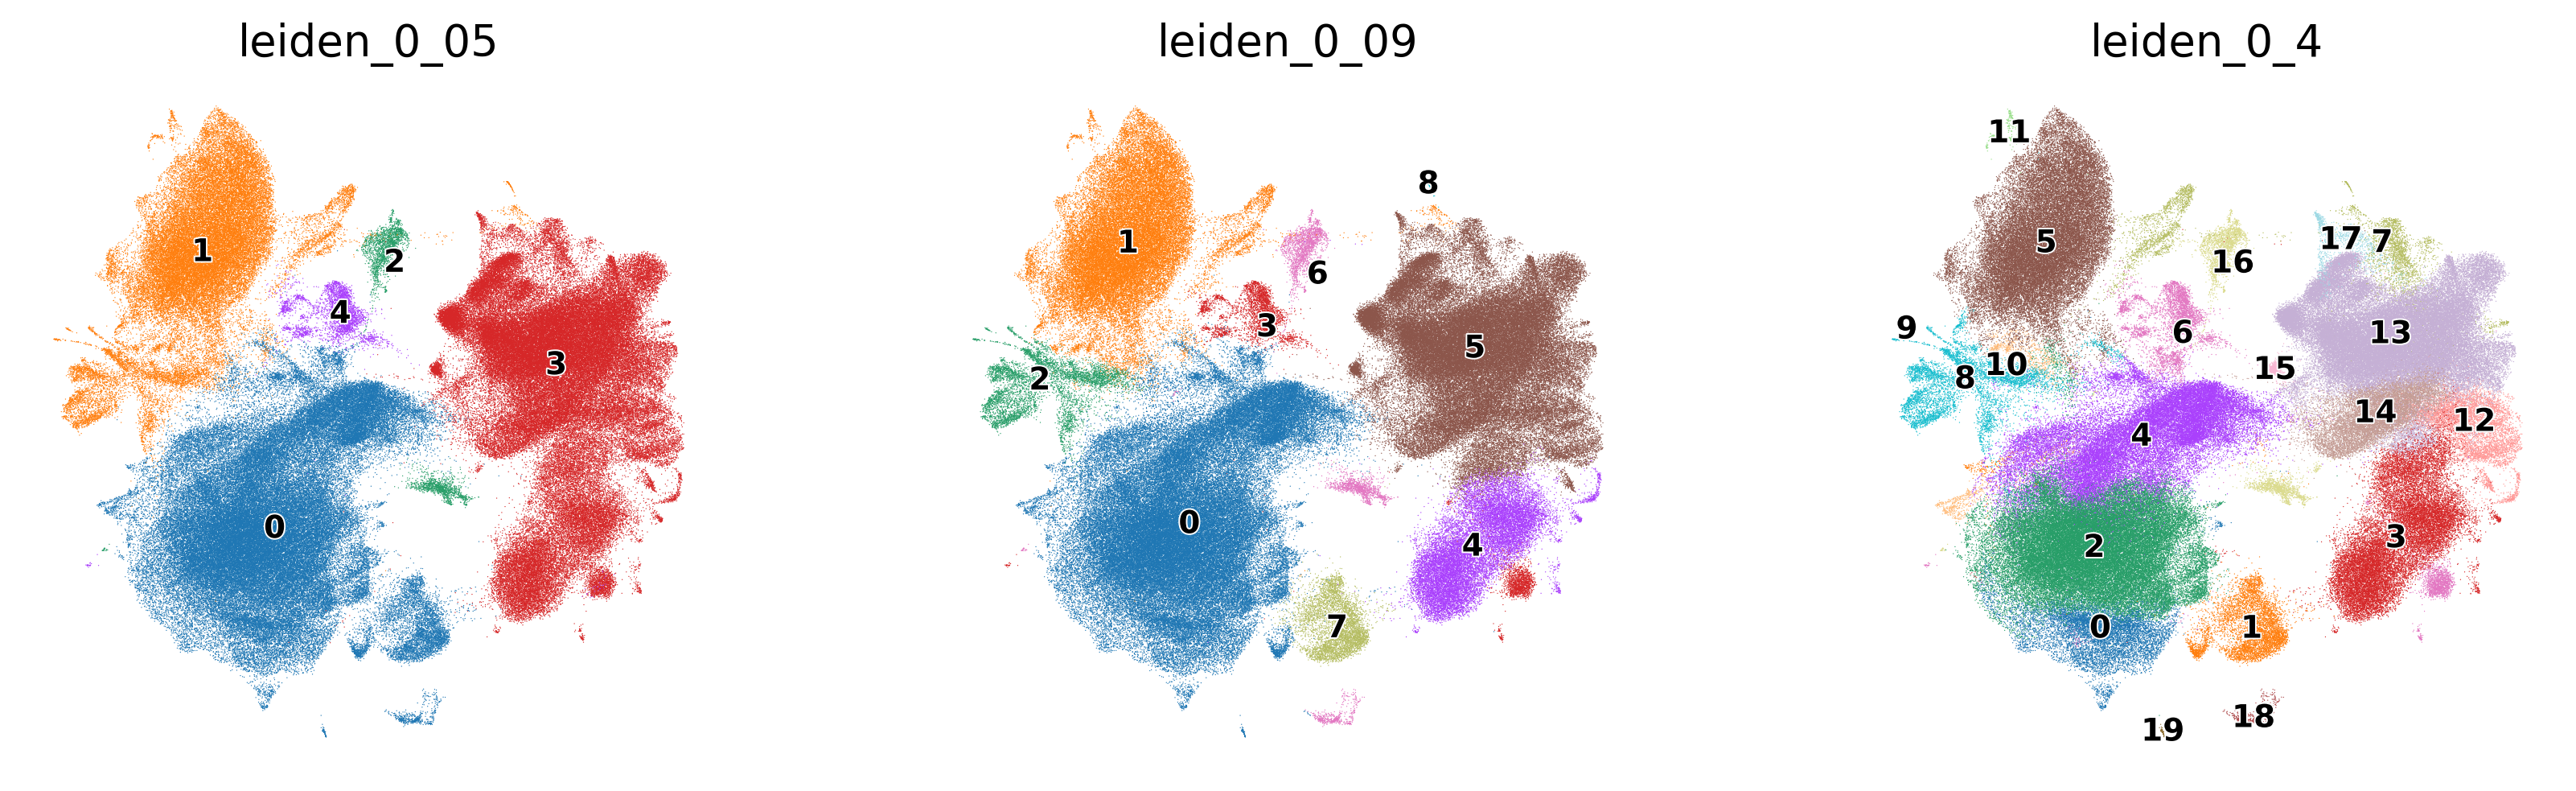

In [ ]:
sc.pl.umap(
    adata,
    color=["leiden_0_05", "leiden_0_09", "leiden_0_4"],
    legend_loc="on data",      # <- instead of "on data"
    legend_fontsize=10,
    legend_fontoutline=1,
)

## Differential expression at Leiden 0.4


In [ ]:
sc.tl.rank_genes_groups(
    adata,
    groupby="leiden_0_4",
    reference="rest",
    n_genes=None,
    method="wilcoxon",
    layer="log1p_norm",
    pts=True,
    key_added="rank_genes_groups_leiden_0_4",
)
adata.write_h5ad(OUTPUT_ROOT / "04_clustered.h5ad", compression="gzip")


### Load clustered checkpoint


In [ ]:
adata = sc.read_h5ad(prefer_checkpoint(
    "04_clustered.h5ad", "2000HVG_rg_cc_mt/clustered_niter.h5ad"
))
adata
